### Imports


In [6]:
import torch
import torch.nn as nn # gives the neural layers,ReLU
import torch.optim as optim # gives the optimizers

In [7]:
from torchvision import (datasets,transforms) # handles downaloading and loading datasets
from torch.utils.data import DataLoader # feeds the images into the network

In [5]:
import matplotlib.pyplot as plt

### Load Data

In [8]:
transform = transforms.Compose(
    [
        transforms.ToTensor(), # convert to tensor, i.e 0-255 into 0.0-1.0
        transforms.Normalize((0.5,), (0.5,)) #shifts the values to be between -1 and 1
    ]
)

In [12]:
train_data = datasets.FashionMNIST(root="data", train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST(root="data",train=False,download=True,transform=transform)
# downloads the data

100.0%
100.0%
100.0%
100.0%


In [13]:
train_loader = DataLoader(dataset=train_data,batch_size=64,shuffle=True)
test_loader = DataLoader(dataset=test_data,batch_size=64,shuffle=True)
# wrapping data into batches so we can loop over it

In [14]:
print(f"Training images: {len(train_data)}")

Training images: 60000


In [16]:
print(f"Test images: {len(test_data)}")

Test images: 10000


### Defining MLP

In [22]:
class FashionMLP(nn.Module): # nn.MOduile is the parent class for every PyTorch model
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential( # op of one layer is fed into another layer
            nn.Flatten(), # flattens the image into a flat list, in this case 28*28 = 784
            nn.Linear(784,128), # 784 inputs and 128 outputs, weitghs are automatically initialized by PyTorch
            nn.ReLU(), # activation function, removes negative values
            nn.Linear(128,64), # 128 inputs and 64 outputs
            nn.ReLU(), # activation function    
            nn.Linear(64,10) # 64 inputs and 10 outputs
        )

    def forward(self,x): # to define what will happen when data is passed forweard
        return self.network(x)
    

In [23]:
model = FashionMLP()

In [24]:
print(model)

FashionMLP(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)


### Counting parameters

In [25]:
total = sum(p.numel() for p in model.parameters())

In [26]:
print(f"The total trainable parameters are: {total:}")

The total trainable parameters are: 109386


### Training

In [27]:
criterion = nn.CrossEntropyLoss()

In [28]:
optimizer = optim.Adam(model.parameters(),lr=0.001)

In [29]:
epochs = 20
train_losses = []
train_accuracies = []

In [32]:
for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        predicted = outputs.argmax(1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    avg_loss = total_loss / len(train_loader)
    accuracy = correct / total * 100

    train_losses.append(avg_loss)
    train_accuracies.append(accuracy)

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%")

Epoch [1/20], Loss: 0.5133, Accuracy: 81.52%
Epoch [2/20], Loss: 0.3763, Accuracy: 86.27%
Epoch [3/20], Loss: 0.3407, Accuracy: 87.46%
Epoch [4/20], Loss: 0.3141, Accuracy: 88.36%
Epoch [5/20], Loss: 0.2978, Accuracy: 88.98%
Epoch [6/20], Loss: 0.2822, Accuracy: 89.55%
Epoch [7/20], Loss: 0.2698, Accuracy: 89.91%
Epoch [8/20], Loss: 0.2587, Accuracy: 90.31%
Epoch [9/20], Loss: 0.2485, Accuracy: 90.63%
Epoch [10/20], Loss: 0.2387, Accuracy: 91.07%
Epoch [11/20], Loss: 0.2309, Accuracy: 91.34%
Epoch [12/20], Loss: 0.2210, Accuracy: 91.64%
Epoch [13/20], Loss: 0.2120, Accuracy: 92.09%
Epoch [14/20], Loss: 0.2067, Accuracy: 92.25%
Epoch [15/20], Loss: 0.1978, Accuracy: 92.46%
Epoch [16/20], Loss: 0.1933, Accuracy: 92.72%
Epoch [17/20], Loss: 0.1876, Accuracy: 92.89%
Epoch [18/20], Loss: 0.1810, Accuracy: 93.18%
Epoch [19/20], Loss: 0.1719, Accuracy: 93.50%
Epoch [20/20], Loss: 0.1706, Accuracy: 93.56%


### Visualization os training

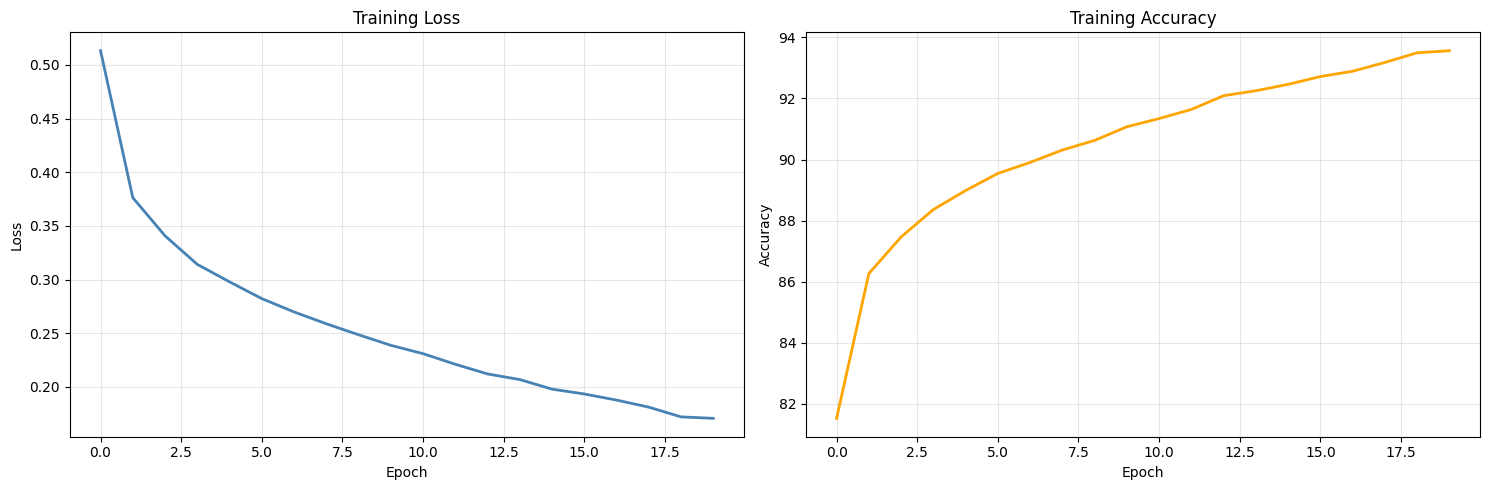

In [36]:
fig , (ax1,ax2) = plt.subplots(1,2,figsize=(15,5))

ax1.plot(train_losses, color="steelblue",linewidth=2)
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True,alpha=0.3)

ax2.plot(train_accuracies, color="orange",linewidth=2)
ax2.set_title("Training Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.grid(True,alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/fashion_mnist_training.png")
plt.show()

### Testing accuracy

In [37]:
model.eval()
correct = 0
total = 0

In [38]:
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        predicted = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {correct / total * 100:.2f}%")

Test Accuracy: 87.47%


### Visualization of prediction

In [39]:
class_names = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [40]:
model.eval()


FashionMLP(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [41]:
images, labels = next(iter(test_loader))

In [42]:
with torch.no_grad():
    outputs = model(images)
    predicted = outputs.argmax(dim=1)
    

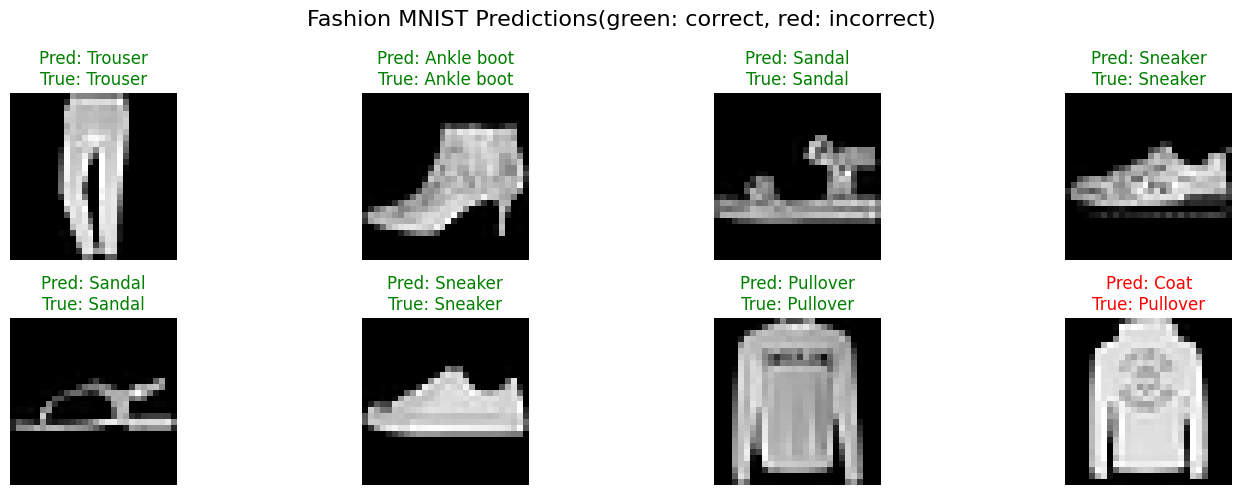

In [45]:
fig, axes = plt.subplots(2, 4, figsize=(15, 5))
axes = axes.flatten()

for i in range(8):
    img = images[i].squeeze()
    axes[i].imshow(img, cmap="gray")
    pred = class_names[predicted[i]]
    true = class_names[labels[i]]
    color = "green" if pred == true else "red"
    axes[i].set_title(f"Pred: {pred}\nTrue: {true}", color=color)
    axes[i].axis("off")

plt.suptitle("Fashion MNIST Predictions(green: correct, red: incorrect)", fontsize=16)
plt.tight_layout()
plt.savefig("../outputs/fashion_mnist_predictions.png")
plt.show()